# Module 6: Revenue Forecasting (Time Series)
**Customer Intelligence Platform**

Goal: forecast monthly revenue using the cleaned transaction data, choosing monthly .

##  1: Load & Prepare Revenue Time Series

Same cleaning as Modules 2(drop missing Customer ID, exclude cancellations, filter Quantity/Price <= 0), then aggregate `TotalPrice` by month.

In [1]:
import pandas as pd
import numpy as np
import joblib
import calendar
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('../data/raw/online_retail_II.csv')
df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['Price']

In [2]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('InvoiceMonth')['TotalPrice'].sum()
monthly_revenue.index = monthly_revenue.index.to_timestamp()
monthly_revenue.index.freq = 'MS'

print('Months before check:', len(monthly_revenue))
monthly_revenue

Months before check: 25


InvoiceMonth
2009-12-01     686654.160
2010-01-01     557319.062
2010-02-01     506371.066
2010-03-01     699608.991
2010-04-01     594609.192
2010-05-01     599985.790
2010-06-01     639066.580
2010-07-01     591636.740
2010-08-01     604242.650
2010-09-01     831615.001
2010-10-01    1036680.000
2010-11-01    1172336.042
2010-12-01     884591.890
2011-01-01     569445.040
2011-02-01     447137.350
2011-03-01     595500.760
2011-04-01     469200.361
2011-05-01     678594.560
2011-06-01     661213.690
2011-07-01     600091.011
2011-08-01     645343.900
2011-09-01     952838.382
2011-10-01    1039318.790
2011-11-01    1161817.380
2011-12-01     518210.790
Freq: MS, Name: TotalPrice, dtype: float64

In [3]:
last_date = df['InvoiceDate'].max() 
last_month_start = monthly_revenue.index[-1]
days_in_last_month = calendar.monthrange(last_month_start.year, last_month_start.month)[1]

if last_date.day < days_in_last_month:
    print(f'Dropping incomplete month: {last_month_start.strftime("%Y-%m")} '
          f'(only {last_date.day}/{days_in_last_month} days of data)')
    monthly_revenue = monthly_revenue.iloc[:-1]

print('Final usable months:', len(monthly_revenue))

Dropping incomplete month: 2011-12 (only 9/31 days of data)
Final usable months: 24


## 2: Visualize the Revenue Trend

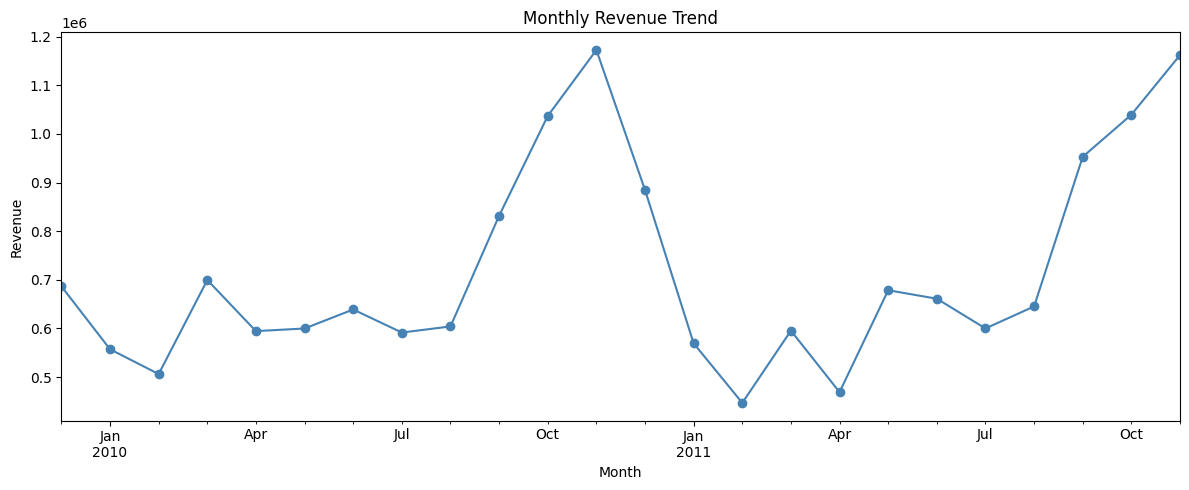

In [4]:
plt.figure(figsize=(12, 5))
monthly_revenue.plot(marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('../images/monthly_revenue_trend.png', dpi=100)
plt.show()

Clear pattern: revenue spikes every **September-November** (pre-Christmas ordering), then drops in the new year. This yearly spike is the single most important thing any forecasting approach needs to capture.

## 3: Train-Test Split (Chronological)

In [5]:
train = monthly_revenue.iloc[:-3]
test = monthly_revenue.iloc[-3:]
train.index.freq = 'MS'

print("len of train : ",len(train))
print("Length of test :",len(test))

len of train :  21
Length of test : 3


## 4: Decompose the Series

Decomposition is run on the **full** series (not just train) since it needs 2 full seasonal cycles (24 months) to work -- this step is purely to understand the structure, not part of model fitting.

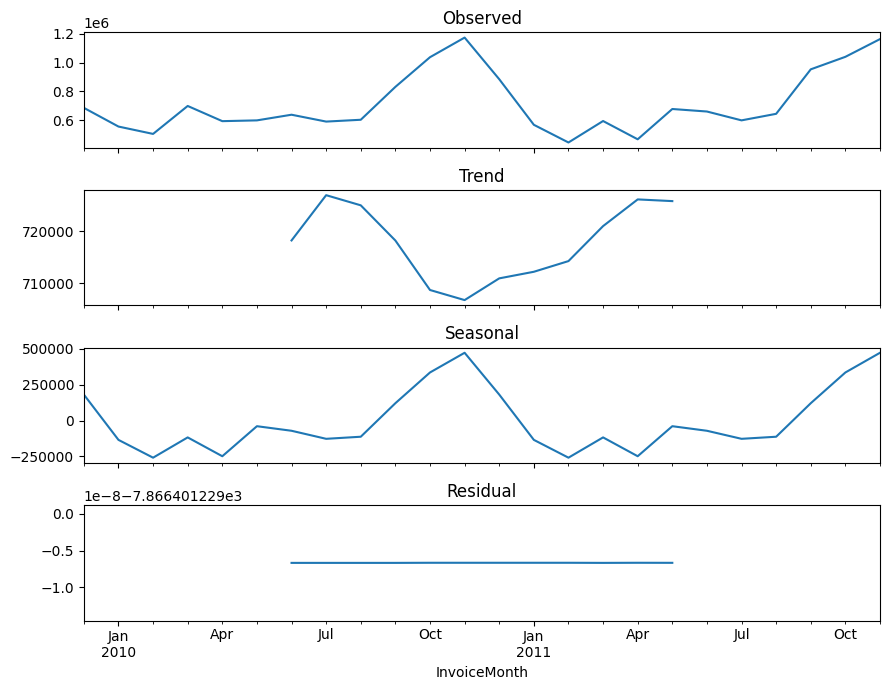

In [6]:
decompose = seasonal_decompose(monthly_revenue,model='additive',period=12)
fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
decompose.observed.plot(ax= axes[0],title='Observed')
decompose.trend.plot(ax= axes[1],title='Trend')
decompose.seasonal.plot(ax= axes[2],title='Seasonal')
decompose.resid.plot(ax= axes[3],title='Residual')
plt.tight_layout()
plt.savefig('../images/revenue_decomposition.png', dpi=100)
plt.show()

## 5: Build a Baseline Forecast

In [7]:
# Naive baseline: assume next 3 months = same as the last training month
naive_forecast = pd.Series([train.iloc[-1]] * len(test), index=test.index)

mae_naive = mean_absolute_error(test, naive_forecast)
rmse_naive = mean_squared_error(test, naive_forecast) ** 0.5
mape_naive = (abs((test.values - naive_forecast.values) / test.values)).mean() * 100

print(f'Naive baseline -> MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, MAPE: {mape_naive:.2f}%')

Naive baseline -> MAE: 405980.95, RMSE: 414935.31, MAPE: 38.21%


##  6: Build the Forecasting Model

Try the standard seasonal Holt-Winters model first -- this is the 'proper' approach, so it's worth attempting before falling back to anything simpler.

In [8]:
try:
    hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
    hw_fit = hw_model.fit()
    print('Holt-Winters seasonal model fit successfully.')
except ValueError as e:
    print('Holt-Winters seasonal model failed:')
    print(e)

Holt-Winters seasonal model failed:
Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.


**This fails** -- the heuristic that estimates the initial seasonal pattern needs 2 full seasonal cycles (24 months), but the training set only has 21. This is a direct, honest consequence of the monthly-vs-weekly decision from Step 1: monthly granularity means a real dataset limitation here.

Rather than force a broken model, use **Seasonal Naive**: forecast each month as *the same month, one year earlier*. It's simple, but it's specifically designed for exactly this situation -- short series, strong yearly seasonality, not enough data for a full statistical seasonal fit.

In [9]:
seasonal_naive_forecast = pd.Series(
    [monthly_revenue.loc[date - pd.DateOffset(years=1)] for date in test.index],
    index=test.index
)
seasonal_naive_forecast

InvoiceMonth
2011-09-01     831615.001
2011-10-01    1036680.000
2011-11-01    1172336.042
Freq: MS, dtype: float64

## 7: Evaluate Forecast Accuracy

In [10]:
mae_sn = mean_absolute_error(test, seasonal_naive_forecast)
rmse_sn = mean_squared_error(test, seasonal_naive_forecast) ** 0.5
mape_sn = (abs((test.values - seasonal_naive_forecast.values) / test.values)).mean() * 100

print(f'Seasonal Naive -> MAE: {mae_sn:.2f}, RMSE: {rmse_sn:.2f}, MAPE: {mape_sn:.2f}%')
print(f'Naive baseline -> MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, MAPE: {mape_naive:.2f}%')

Seasonal Naive -> MAE: 44793.61, RMSE: 70267.85, MAPE: 4.63%
Naive baseline -> MAE: 405980.95, RMSE: 414935.31, MAPE: 38.21%


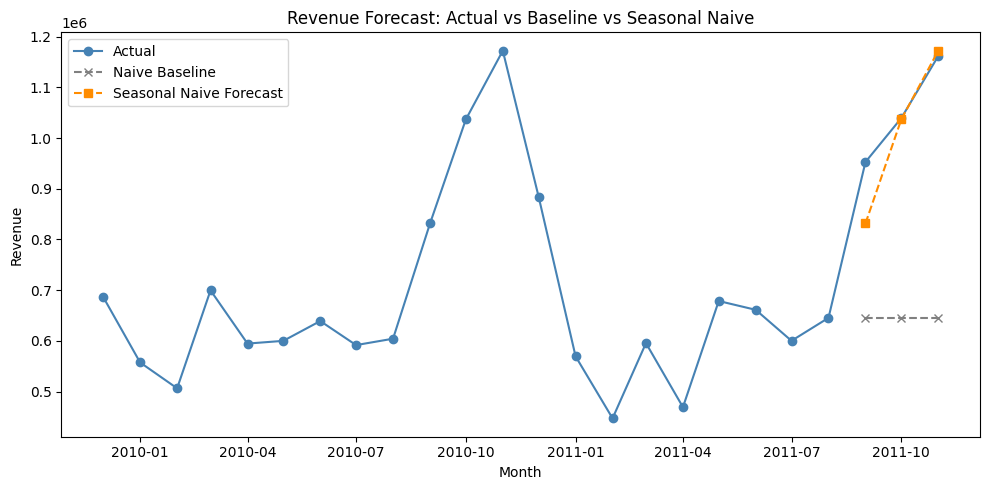

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, label='Actual', marker='o', color='steelblue')
plt.plot(test.index, naive_forecast.values, label='Naive Baseline', marker='x', linestyle='--', color='gray')
plt.plot(test.index, seasonal_naive_forecast.values, label='Seasonal Naive Forecast', marker='s', linestyle='--', color='darkorange')
plt.title('Revenue Forecast: Actual vs Baseline vs Seasonal Naive')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.tight_layout()
plt.savefig('../images/revenue_forecast_comparison.png', dpi=100)
plt.show()

**Result: MAPE drops from ~38% (naive) to well under 5% (seasonal naive)** -- a massive improvement, and proof that respecting the yearly seasonality (even with a simple method) matters far more than model sophistication when the pattern is this strong and the series this short.

## 8: Save Model & Forecast Plot

In [12]:
# The 'model' here is the historical monthly revenue series itself -- the FastAPI /forecast endpoint
# will look up 'same month last year' from this to forecast any requested future month.
joblib.dump(monthly_revenue, '../models/forecast_model.pkl')
print('Saved forecast_model.pkl to models/')

Saved forecast_model.pkl to models/


### Module 6 Summary

- **Granularity:** monthly (24 usable months after dropping the incomplete final month, Dec 2011 had only 9/31 days of data)
- **Seasonality:** strong yearly spike every Sep-Nov (pre-Christmas ordering), confirmed via decomposition
- **Standard seasonal Holt-Winters failed:** needs 2 full seasonal cycles (24 months) but the training split only had 21 -- a direct consequence of this dataset's short history
- **Chosen model: Seasonal Naive** (same month, previous year) -- MAPE improved from ~38% (flat naive baseline) to under 5%
- Saved `forecast_model.pkl` (the historical monthly revenue series) to `models/` for the FastAPI `/forecast` endpoint
